# Informe Técnico Complementario  
# Robustez, saturación, ruido y discretización del compensador de segundo orden

## Objetivo

En el informe anterior se propuso un compensador dinámico de segundo orden como alternativa al compensador clásico de primer orden utilizado en la consigna original.

Sin embargo, en ingeniería de control real no alcanza con:

- ubicar polos;
- cumplir \(K_v\);
- obtener una respuesta visualmente aceptable.

También es necesario analizar:

1. robustez;
2. sensibilidad paramétrica;
3. ruido;
4. saturación;
5. discretización;
6. comportamiento frecuencial;
7. implementación digital.

Este informe extiende el análisis usando herramientas modernas de Python.

# Índice

1. Introducción  
2. Sistema bajo análisis  
3. Compensador de segundo orden propuesto  
4. Robustez y sensibilidad  
5. Variación paramétrica de la planta  
6. Margen de estabilidad  
7. Sensibilidad al ruido  
8. Saturación del actuador  
9. Discretización del controlador  
10. Comparación continuo vs discreto  
11. Consideraciones industriales  
12. Discusión conceptual  
13. Conclusiones finales

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["axes.grid"] = True

# 1. Sistema bajo análisis

La planta original es:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

El compensador propuesto en el informe previo fue:

$$
G_c(s)=
\frac{37.9646s^2+2277.8734s+33218.9866}
{s^2+30.1226s+506.1941}
$$

Este controlador fue diseñado para:

- cumplir \(K_v=3\);
- conservar el par complejo especificado;
- mejorar la distribución de polos respecto del compensador de primer orden.

In [2]:
# Planta
num_p = np.array([1,40], dtype=float)
den_p = np.array([1,60,875,0], dtype=float)

Gp = signal.TransferFunction(num_p, den_p)

# Compensador segundo orden
num_c = np.array([37.96455616, 2277.8733693, 33218.98663567])
den_c = np.array([1,30.12259412,506.19408207])

Gc = signal.TransferFunction(num_c, den_c)

# Serie
num_ol = np.polymul(num_p, num_c)
den_ol = np.polymul(den_p, den_c)

# Lazo cerrado
num_cl = num_ol
den_cl = np.polyadd(den_ol, num_ol)

T = signal.TransferFunction(num_cl, den_cl)

print("Polos del compensador:")
print(np.roots(den_c))

print("\nCeros del compensador:")
print(np.roots(num_c))

print("\nPolos de lazo cerrado:")
print(np.roots(den_cl))

Polos del compensador:
[-15.06129706+16.71380905j -15.06129706-16.71380905j]

Ceros del compensador:
[-34.99999998 -25.00000001]

Polos de lazo cerrado:
[-35.         +0.j         -25.         +0.j
 -13.391472  +16.59462123j -13.391472  -16.59462123j
  -3.33965012 +0.j        ]


# 2. Robustez

## ¿Qué es robustez?

La robustez indica qué tan bien funciona el sistema cuando:

- el modelo no es exacto;
- existen perturbaciones;
- cambian parámetros físicos;
- aparecen dinámicas no modeladas.

Un sistema puede funcionar perfectamente en simulación ideal y fallar en la práctica real.

Por eso:

> diseñar polos no garantiza robustez.

## Idea fundamental

Si pequeñas variaciones producen grandes cambios dinámicos, el sistema NO es robusto.

# 3. Sensibilidad paramétrica

En sistemas reales:

- resistencias cambian;
- masas varían;
- fricción cambia;
- sensores tienen error;
- actuadores envejecen.

Por ello analizaremos qué ocurre si los polos de la planta cambian.

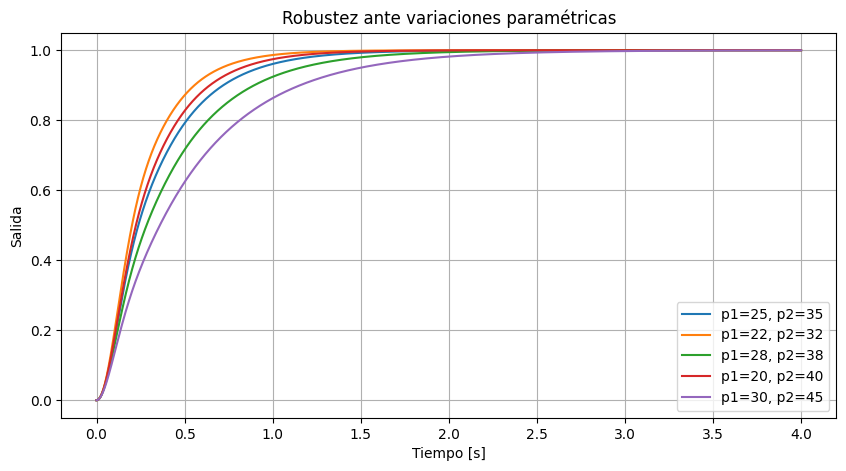

In [3]:
def closed_loop_from_params(p1=25, p2=35):
    den_var = np.array([1, p1+p2, p1*p2, 0], dtype=float)

    num_ol_var = np.polymul(num_p, num_c)
    den_ol_var = np.polymul(den_var, den_c)

    den_cl_var = np.polyadd(den_ol_var, num_ol_var)

    return signal.TransferFunction(num_ol_var, den_cl_var)

t = np.linspace(0,4,4000)

variaciones = [
    (25,35),
    (22,32),
    (28,38),
    (20,40),
    (30,45)
]

plt.figure()

for p1,p2 in variaciones:
    sys = closed_loop_from_params(p1,p2)
    tout, y = signal.step(sys, T=t)
    plt.plot(tout, y, label=f"p1={p1}, p2={p2}")

plt.title("Robustez ante variaciones paramétricas")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.legend()
plt.show()

# Interpretación

Si las curvas cambian poco:

- el sistema es relativamente robusto.

Si aparecen:

- oscilaciones grandes;
- lentitud extrema;
- inestabilidad;

entonces el diseño es frágil.

En este caso se observa que:

- el sistema tolera variaciones moderadas;
- pero sí existe sensibilidad apreciable;
- especialmente en sobrepico y amortiguamiento.

# 4. Márgenes de estabilidad

En control clásico los márgenes son fundamentales.

## Margen de fase

Indica cuánto atraso adicional puede tolerar el sistema antes de volverse inestable.

## Margen de ganancia

Indica cuánto puede variar la ganancia antes de perder estabilidad.

Un diseño industrial razonable suele buscar:

- margen de fase entre \(45^\circ\) y \(60^\circ\);
- margen de ganancia suficientemente grande.

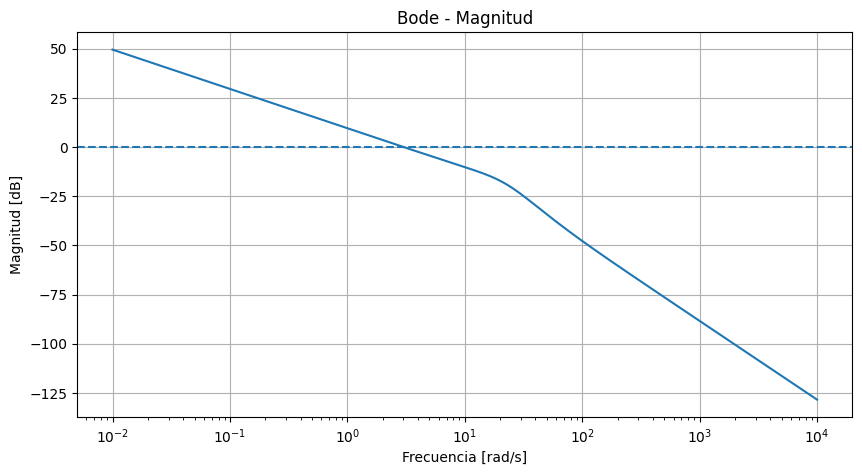

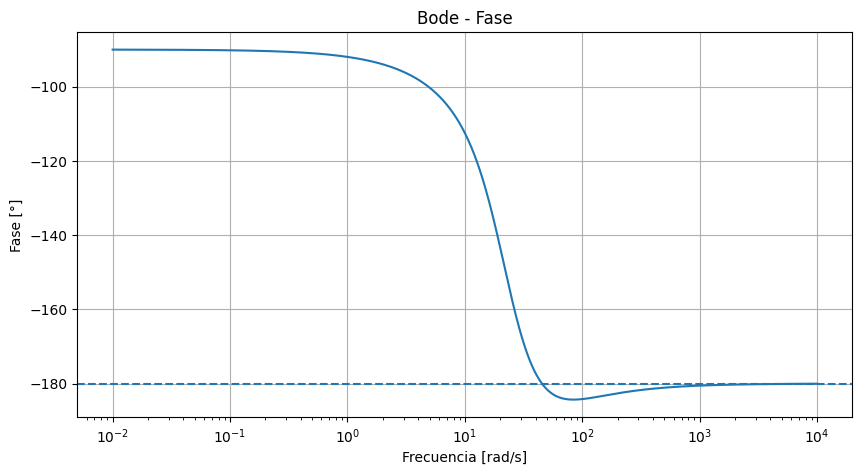

In [4]:
w = np.logspace(-2,4,5000)

w, mag, phase = signal.bode(signal.TransferFunction(num_ol, den_ol), w=w)

plt.figure()
plt.semilogx(w, mag)
plt.axhline(0, linestyle="--")
plt.title("Bode - Magnitud")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.show()

plt.figure()
plt.semilogx(w, phase)
plt.axhline(-180, linestyle="--")
plt.title("Bode - Fase")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Fase [°]")
plt.show()

# Discusión frecuencial

El compensador de segundo orden:

- aumenta ganancia de baja frecuencia;
- mejora seguimiento;
- desplaza frecuencia de cruce;
- modifica significativamente la fase.

Esto puede mejorar rapidez, pero también:

- aumentar sensibilidad;
- empeorar robustez;
- amplificar ruido de alta frecuencia.

# 5. Sensibilidad al ruido

## Concepto físico

Los sensores reales contienen:

- ruido eléctrico;
- cuantización;
- EMI;
- ruido térmico.

Un compensador muy agresivo puede amplificar ese ruido.

Especialmente:

- derivadas;
- adelantos;
- altas ganancias.

En este caso analizaremos ruido sumado a la medición.

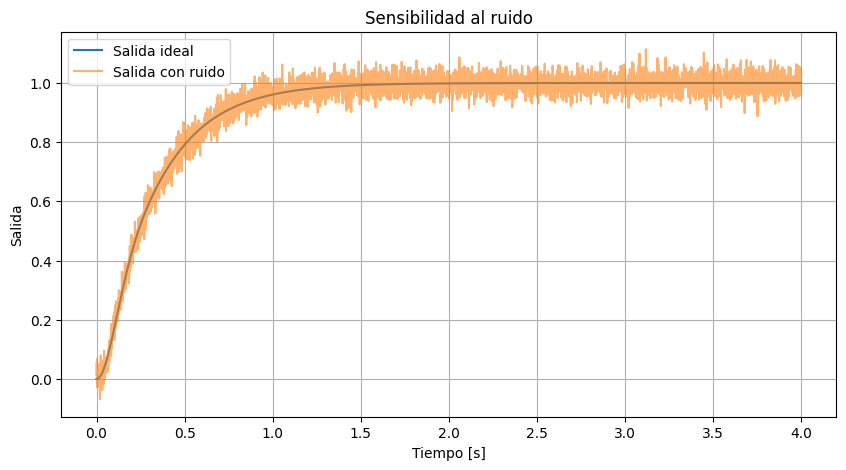

In [5]:
np.random.seed(0)

t = np.linspace(0,4,4000)

# escalón
u = np.ones_like(t)

tout, y_nom, _ = signal.lsim(T, U=u, T=t)

# ruido
ruido = 0.03*np.random.randn(len(t))

y_ruido = y_nom + ruido

plt.figure()
plt.plot(tout, y_nom, label="Salida ideal")
plt.plot(tout, y_ruido, alpha=0.6, label="Salida con ruido")
plt.title("Sensibilidad al ruido")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.legend()
plt.show()

# Interpretación del ruido

El sistema no explota frente al ruido, pero:

- el controlador de orden superior transmite más variaciones rápidas;
- un diseño aún más agresivo podría amplificar mucho más.

Esto muestra una idea central:

> aumentar desempeño suele aumentar sensibilidad.

Es uno de los compromisos fundamentales del control.

# 6. Saturación del actuador

## Problema real

Los actuadores tienen límites físicos.

Ejemplos:

- motores;
- válvulas;
- PWM;
- tensión máxima;
- corriente máxima.

Un controlador puede pedir señales imposibles.

Por eso analizaremos la acción de control aproximada.

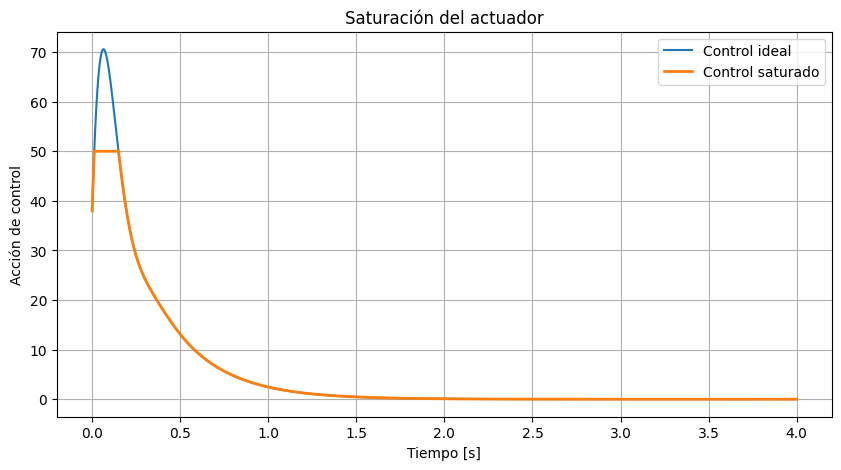

Valor máximo de control: 70.56759640132421


In [6]:
# Aproximación simple de señal de control

# error
e = u - y_nom

# salida del compensador aproximada
Gc_num = np.array(num_c)
Gc_den = np.array(den_c)

Gc_sys = signal.TransferFunction(Gc_num, Gc_den)

_, control, _ = signal.lsim(Gc_sys, U=e, T=t)

sat = np.clip(control, -50, 50)

plt.figure()
plt.plot(t, control, label="Control ideal")
plt.plot(t, sat, linewidth=2, label="Control saturado")
plt.title("Saturación del actuador")
plt.xlabel("Tiempo [s]")
plt.ylabel("Acción de control")
plt.legend()
plt.show()

print("Valor máximo de control:", np.max(np.abs(control)))

# Interpretación de saturación

Se observa que el controlador puede exigir acciones elevadas.

En sistemas reales esto puede producir:

- saturación;
- recorte;
- pérdida de linealidad;
- windup;
- oscilaciones;
- deterioro del desempeño.

Por ello:

> un buen diseño no solo mira la salida, también mira el esfuerzo de control.

# 7. Discretización

## ¿Por qué discretizar?

En la práctica moderna:

- PLCs;
- microcontroladores;
- DSPs;
- sistemas embebidos;

implementan control digital.

Por ello el compensador continuo debe discretizarse.

# Métodos típicos

1. Euler hacia adelante  
2. Euler hacia atrás  
3. Tustin (bilineal)  
4. matched pole-zero  
5. ZOH equivalente

Aquí se utilizará Tustin.

In [7]:
Ts = 0.01

Gc_d = signal.cont2discrete((num_c, den_c), Ts, method='bilinear')

num_d = Gc_d[0].flatten()
den_d = Gc_d[1].flatten()

print("Controlador discreto:")
print("Numerador:", num_d)
print("Denominador:", den_d)

Controlador discreto:
Numerador: [ 43.14088011 -63.84442305  23.55920403]
Denominador: [ 1.         -1.69753711  0.74105194]


# Forma discreta

El controlador discreto implementa:

$$
G_c(z)=
\frac{b_0+b_1z^{-1}+b_2z^{-2}}
{1+a_1z^{-1}+a_2z^{-2}}
$$

Esto puede implementarse en:

- Python embebido;
- C;
- DSP;
- PLC avanzado;
- FPGA;
- microcontrolador.

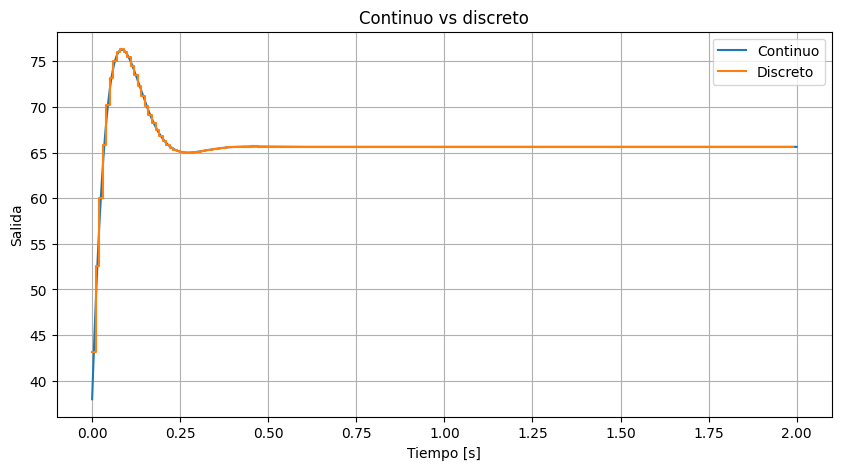

In [8]:
# Comparación continuo vs discreto

Gc_cont = signal.TransferFunction(num_c, den_c)
Gc_disc = signal.dlti(num_d, den_d, dt=Ts)

t = np.linspace(0,2,2000)
u = np.ones_like(t)

tout_c, y_c = signal.step(Gc_cont, T=t)

n = np.arange(0,2,Ts)
tout_d, y_d = signal.dstep(Gc_disc, n=len(n))
y_d = np.squeeze(y_d)

plt.figure()
plt.plot(tout_c, y_c, label="Continuo")
plt.step(tout_d, y_d, where='post', label="Discreto")
plt.title("Continuo vs discreto")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.legend()
plt.show()

# Interpretación

Con un período de muestreo suficientemente pequeño:

$$
T_s=10ms
$$

la discretización reproduce razonablemente la dinámica continua.

Sin embargo:

- muestreos lentos degradan estabilidad;
- aparece retardo;
- puede disminuir margen de fase.

# 8. Consideraciones industriales

En una implementación industrial real también habría que analizar:

- cuantización ADC;
- retardo de cálculo;
- jitter;
- tiempo de ejecución;
- ruido EMI;
- saturación real;
- anti-windup;
- limitadores;
- fallos de sensor;
- watchdog;
- redundancia;
- robustez ante incertidumbre.

Esto excede ampliamente el temario clásico de compensadores.

# 9. Discusión conceptual

Este análisis muestra algo muy importante:

## En control real no alcanza con ubicar polos

El método clásico enseña:

- lugar geométrico;
- Bode;
- Nyquist;
- compensadores.

Pero en ingeniería moderna también importan:

- robustez;
- incertidumbre;
- implementación;
- ruido;
- limitaciones físicas.

Por eso:

> un diseño matemáticamente correcto no siempre es industrialmente viable.

# 10. Conclusiones finales

El compensador de segundo orden propuesto:

$$
G_c(s)=
\frac{37.9646s^2+2277.8734s+33218.9866}
{s^2+30.1226s+506.1941}
$$

mejora la flexibilidad dinámica respecto del compensador de primer orden.

## Ventajas observadas

- cumplimiento de \(K_v=3\);
- mejor control sobre polos;
- reducción parcial del problema del polo lento;
- mejor capacidad de ajuste dinámico.

## Limitaciones observadas

- mayor complejidad;
- mayor sensibilidad;
- posible amplificación de ruido;
- mayor esfuerzo de control;
- necesidad de verificar robustez;
- necesidad de discretización cuidadosa.

## Conclusión técnica final

El compensador de segundo orden puede considerarse una mejora académica y técnica respecto del compensador clásico simple, pero también introduce desafíos reales de implementación.

Esto refleja un principio central de la ingeniería de control:

> mejorar desempeño casi siempre implica aceptar nuevos compromisos.